In [2]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

DATA_DIR = Path('../data')
PM_FEE = 0.02

In [3]:
def load_trades(path: Path) -> pd.DataFrame:
    df = pq.read_table(path).to_pandas()
    df = df[df['resolved_yes'].notna()].copy()
    df['resolved_yes'] = df['resolved_yes'].astype(bool)
    df['opened_at'] = pd.to_datetime(df['opened_at'], utc=True)
    df = df.sort_values('opened_at').reset_index(drop=True)
    return df

model_df = load_trades(DATA_DIR / 'trades/trades.parquet')
analysis_df = load_trades(DATA_DIR / 'analysis_trades/trades.parquet')

print(f'Model trades:    {len(model_df):,} resolved')
print(f'Analysis trades: {len(analysis_df):,} resolved')

Model trades:    9,251 resolved
Analysis trades: 6,948 resolved


## 1. Overall summary

In [4]:
def summary(df: pd.DataFrame, label: str) -> None:
    wins = df['resolved_yes'].sum()
    total = len(df)
    pnl = df['pnl'].sum()
    roi = 100 * pnl / (total * df['stake'].iloc[0])
    avg_edge = df['edge'].mean()
    avg_pred = df['predicted_prob'].mean()
    print(f'--- {label} ---')
    print(f'  Trades:        {total:,}')
    print(f'  Win rate:      {100*wins/total:.1f}%  ({wins}/{total})')
    print(f'  Total P&L:     ${pnl:+.2f}')
    print(f'  ROI:           {roi:+.1f}%')
    print(f'  Avg edge:      {avg_edge:+.4f}')
    print(f'  Avg pred prob: {avg_pred:.3f}')
    print()

summary(model_df, 'Model (logistic regression)')
summary(analysis_df, 'Analysis (empirical lookup)')

--- Model (logistic regression) ---
  Trades:        9,251
  Win rate:      74.1%  (6851/9251)
  Total P&L:     $+1503.92
  ROI:           +16.3%
  Avg edge:      +0.1404
  Avg pred prob: 0.829

--- Analysis (empirical lookup) ---
  Trades:        6,948
  Win rate:      68.4%  (4752/6948)
  Total P&L:     $+435.64
  ROI:           +6.3%
  Avg edge:      +0.1943
  Avg pred prob: 0.856



## 2. Cumulative P&L over time

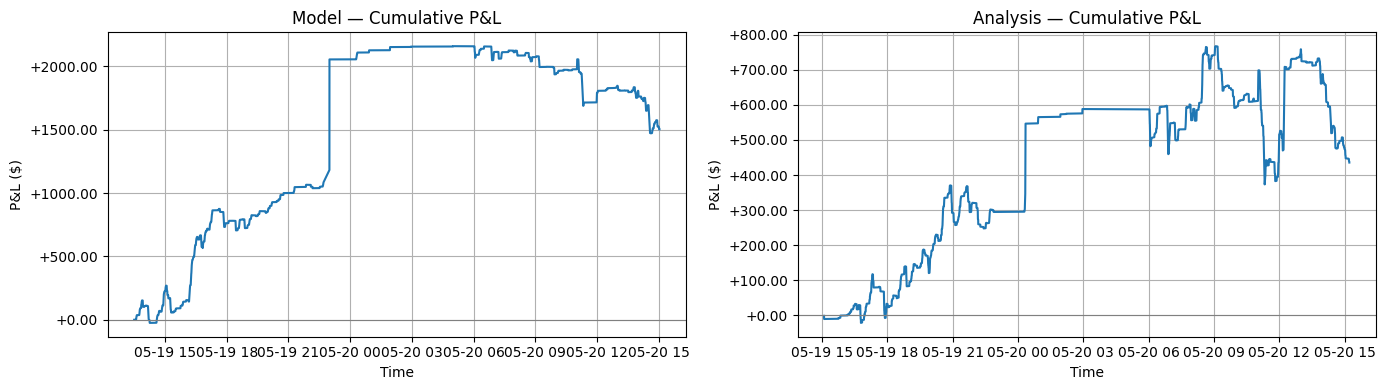

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, label in [
    (axes[0], model_df, 'Model'),
    (axes[1], analysis_df, 'Analysis'),
]:
    cum_pnl = df['pnl'].cumsum()
    ax.plot(df['opened_at'], cum_pnl)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(f'{label} — Cumulative P&L')
    ax.set_xlabel('Time')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.2f'))

plt.tight_layout()
plt.show()

## 3. Edge threshold sweep
What happens to win rate, trade count, and total P&L as we raise the minimum edge required?

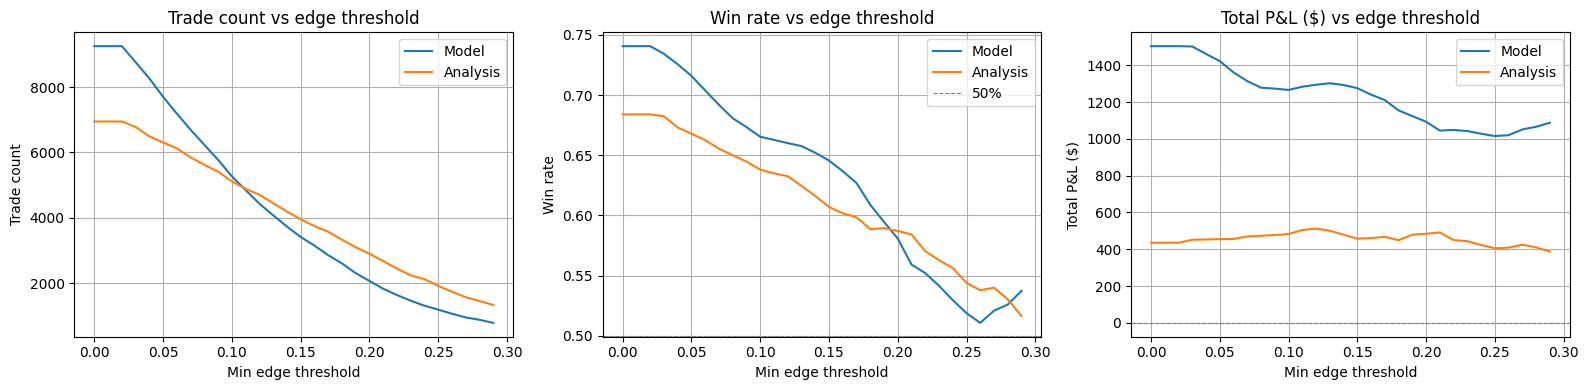

Model best P&L by threshold:
 threshold    n  win_rate   total_pnl       roi
      0.00 9251  0.740569 1503.916547 16.256800
      0.02 9251  0.740569 1503.916547 16.256800
      0.01 9251  0.740569 1503.916547 16.256800
      0.03 8762  0.734193 1502.213372 17.144640
      0.04 8263  0.725523 1461.622634 17.688765

Analysis best P&L by threshold:
 threshold    n  win_rate  total_pnl       roi
      0.12 4708  0.632540 512.667436 10.889283
      0.11 4890  0.634969 504.747449 10.322034
      0.13 4451  0.624579 501.022587 11.256405
      0.21 2679  0.584173 491.345152 18.340618
      0.20 2904  0.587121 484.484185 16.683340


In [6]:
def edge_sweep(df: pd.DataFrame, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.00, 0.30, 0.01)
    rows = []
    for t in thresholds:
        sub = df[df['edge'] >= t]
        if len(sub) == 0:
            rows.append({'threshold': t, 'n': 0, 'win_rate': np.nan, 'total_pnl': 0, 'roi': np.nan})
            continue
        wins = sub['resolved_yes'].sum()
        pnl = sub['pnl'].sum()
        rows.append({
            'threshold': t,
            'n': len(sub),
            'win_rate': wins / len(sub),
            'total_pnl': pnl,
            'roi': 100 * pnl / (len(sub) * df['stake'].iloc[0]),
        })
    return pd.DataFrame(rows)

model_sweep = edge_sweep(model_df)
analysis_sweep = edge_sweep(analysis_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, ylabel in [
    (axes[0], 'n', 'Trade count'),
    (axes[1], 'win_rate', 'Win rate'),
    (axes[2], 'total_pnl', 'Total P&L ($)'),
]:
    ax.plot(model_sweep['threshold'], model_sweep[col], label='Model')
    ax.plot(analysis_sweep['threshold'], analysis_sweep[col], label='Analysis')
    if col == 'win_rate':
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50%')
    if col == 'total_pnl':
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Min edge threshold')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + ' vs edge threshold')
    ax.legend()

plt.tight_layout()
plt.show()

print('Model best P&L by threshold:')
print(model_sweep.sort_values('total_pnl', ascending=False).head(5).to_string(index=False))
print()
print('Analysis best P&L by threshold:')
print(analysis_sweep.sort_values('total_pnl', ascending=False).head(5).to_string(index=False))

## 3b. Does the 0.7 predicted probability floor add value?
If the model is well-calibrated, any trade with a positive edge should be profitable regardless of the absolute predicted probability.
Here we sweep `min_predicted_prob` and also compare trades below vs above 0.7 directly.

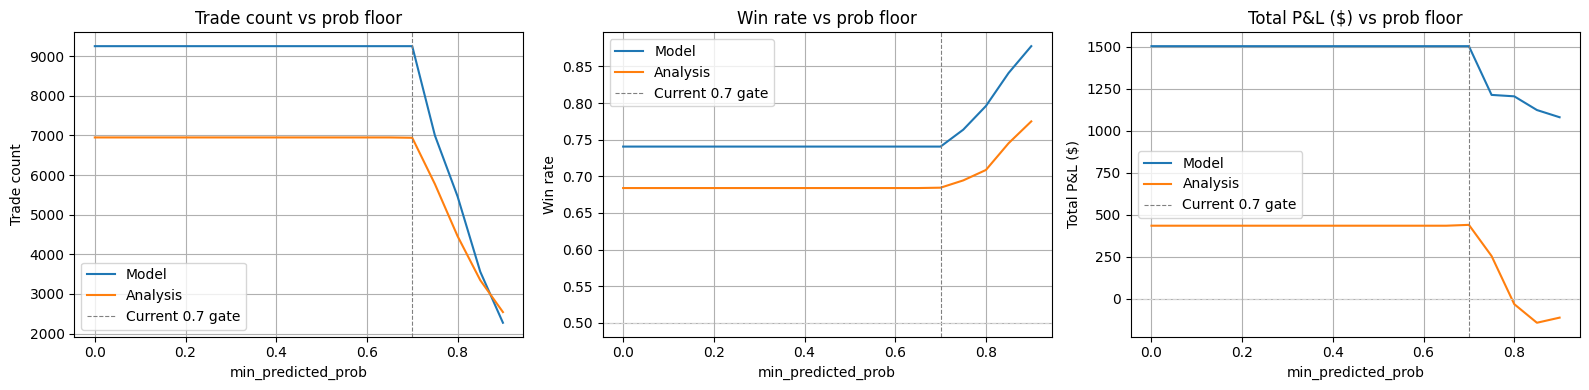

                                                        Model                        Analysis
                                 trades   win%      P&L     ROI    trades   win%      P&L     ROI
----------------------------------------------------------------------------------------------------
edge>=0.02, prob < 0.7                0      —        —       —         0      —        —       —
edge>=0.02, prob >= 0.7           9,251  74.1% +1503.92  +16.3%     6,948  68.4%  +435.64   +6.3%
edge>=0.02, any prob              9,251  74.1% +1503.92  +16.3%     6,948  68.4%  +435.64   +6.3%


In [7]:
MIN_EDGE = 0.02  # keep edge gate fixed, only vary the prob floor

# --- sweep min_predicted_prob ---
def prob_sweep(df: pd.DataFrame, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.0, 0.95, 0.05)
    rows = []
    for t in thresholds:
        sub = df[(df['edge'] >= MIN_EDGE) & (df['predicted_prob'] >= t)]
        if len(sub) == 0:
            rows.append({'min_prob': t, 'n': 0, 'win_rate': np.nan, 'total_pnl': 0, 'roi': np.nan})
            continue
        pnl = sub['pnl'].sum()
        rows.append({
            'min_prob': t,
            'n': len(sub),
            'win_rate': sub['resolved_yes'].mean(),
            'total_pnl': pnl,
            'roi': 100 * pnl / (len(sub) * df['stake'].iloc[0]),
        })
    return pd.DataFrame(rows)

model_psweep = prob_sweep(model_df)
analysis_psweep = prob_sweep(analysis_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, ylabel in [
    (axes[0], 'n', 'Trade count'),
    (axes[1], 'win_rate', 'Win rate'),
    (axes[2], 'total_pnl', 'Total P&L ($)'),
]:
    ax.plot(model_psweep['min_prob'], model_psweep[col], label='Model')
    ax.plot(analysis_psweep['min_prob'], analysis_psweep[col], label='Analysis')
    ax.axvline(0.7, color='gray', linestyle='--', linewidth=0.8, label='Current 0.7 gate')
    if col == 'win_rate':
        ax.axhline(0.5, color='lightgray', linestyle='--', linewidth=0.8)
    if col == 'total_pnl':
        ax.axhline(0, color='lightgray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('min_predicted_prob')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + ' vs prob floor')
    ax.legend()

plt.tight_layout()
plt.show()

# --- direct comparison: below vs above 0.7 ---
print(f"{'':30s} {'Model':>30s}  {'Analysis':>30s}")
print(f"{'':30s} {'trades':>8} {'win%':>6} {'P&L':>8} {'ROI':>7}  {'trades':>8} {'win%':>6} {'P&L':>8} {'ROI':>7}")
print('-' * 100)
for label, m_sub, a_sub in [
    ('edge>=0.02, prob < 0.7',
     model_df[(model_df['edge'] >= MIN_EDGE) & (model_df['predicted_prob'] < 0.7)],
     analysis_df[(analysis_df['edge'] >= MIN_EDGE) & (analysis_df['predicted_prob'] < 0.7)]),
    ('edge>=0.02, prob >= 0.7',
     model_df[(model_df['edge'] >= MIN_EDGE) & (model_df['predicted_prob'] >= 0.7)],
     analysis_df[(analysis_df['edge'] >= MIN_EDGE) & (analysis_df['predicted_prob'] >= 0.7)]),
    ('edge>=0.02, any prob',
     model_df[model_df['edge'] >= MIN_EDGE],
     analysis_df[analysis_df['edge'] >= MIN_EDGE]),
]:
    def fmt(sub):
        if len(sub) == 0:
            return f"{'0':>8} {'—':>6} {'—':>8} {'—':>7}"
        pnl = sub['pnl'].sum()
        roi = 100 * pnl / (len(sub) * sub['stake'].iloc[0])
        return f"{len(sub):>8,} {100*sub['resolved_yes'].mean():>5.1f}% {pnl:>+8.2f} {roi:>+6.1f}%"
    print(f"{label:30s} {fmt(m_sub)}  {fmt(a_sub)}")

## 4. Calibration
Does predicted_prob match the actual win rate? A well-calibrated model at 0.75 should win ~75% of the time.

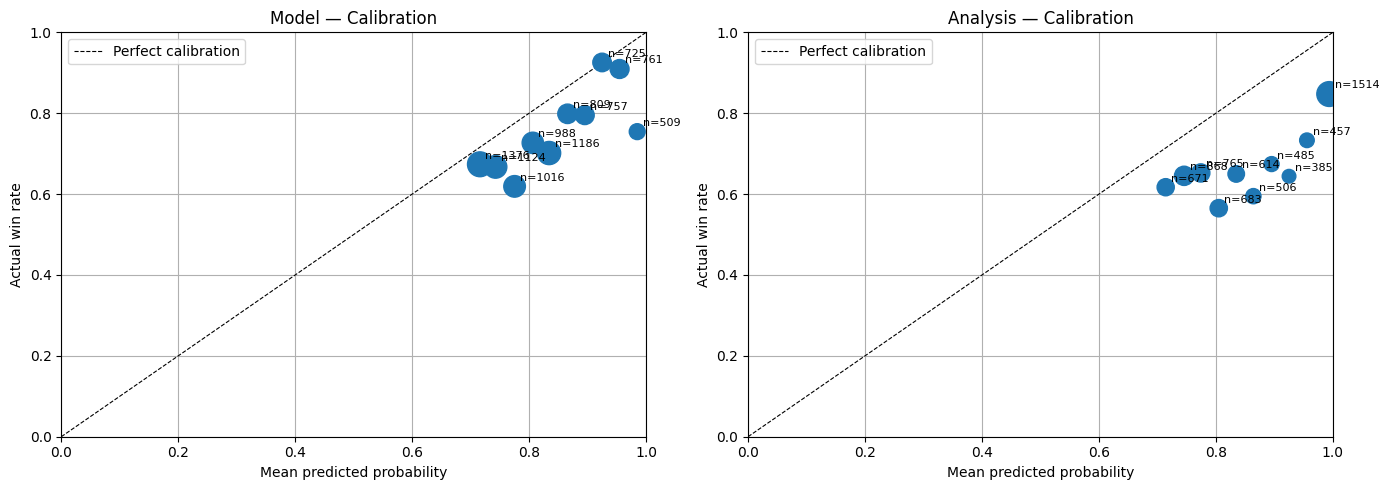

In [8]:
def calibration_bins(df: pd.DataFrame, n_bins=10):
    df = df.copy()
    df['prob_bin'] = pd.cut(df['predicted_prob'], bins=n_bins)
    cal = df.groupby('prob_bin', observed=True).agg(
        n=('resolved_yes', 'count'),
        actual_win_rate=('resolved_yes', 'mean'),
        mean_pred=('predicted_prob', 'mean'),
    ).dropna()
    return cal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label in [
    (axes[0], model_df, 'Model'),
    (axes[1], analysis_df, 'Analysis'),
]:
    cal = calibration_bins(df)
    ax.scatter(cal['mean_pred'], cal['actual_win_rate'], s=cal['n']/cal['n'].max()*300+20, zorder=3)
    for _, row in cal.iterrows():
        ax.annotate(f"n={int(row['n'])}", (row['mean_pred'], row['actual_win_rate']),
                    textcoords='offset points', xytext=(4, 4), fontsize=8)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Actual win rate')
    ax.set_title(f'{label} — Calibration')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. P&L by time_remaining
Is the edge concentrated early or late in the candle?

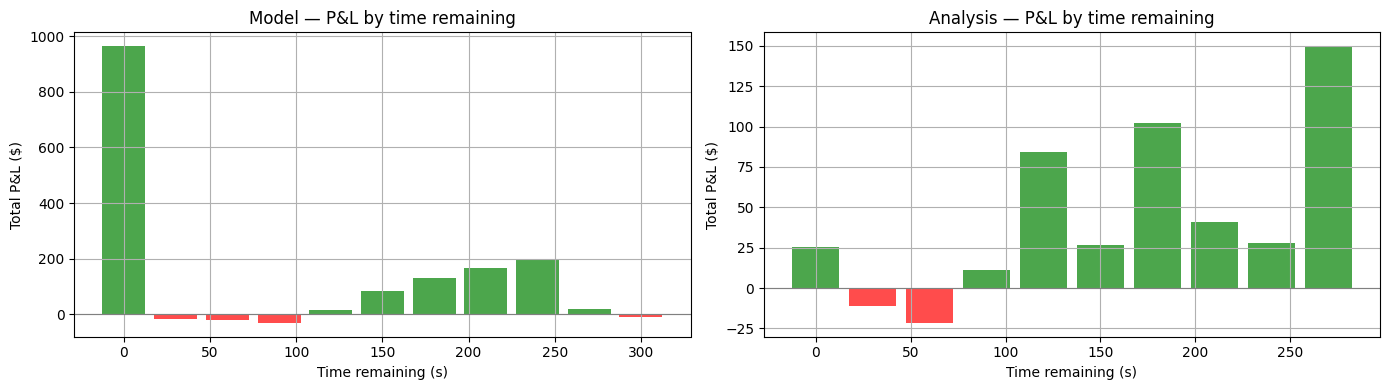

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, label in [
    (axes[0], model_df, 'Model'),
    (axes[1], analysis_df, 'Analysis'),
]:
    df = df.copy()
    df['time_bucket'] = (df['time_remaining'] // 30) * 30
    grp = df.groupby('time_bucket').agg(
        n=('pnl', 'count'),
        total_pnl=('pnl', 'sum'),
        win_rate=('resolved_yes', 'mean'),
    ).reset_index()

    color = ['green' if p >= 0 else 'red' for p in grp['total_pnl']]
    ax.bar(grp['time_bucket'], grp['total_pnl'], width=25, color=color, alpha=0.7)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('Time remaining (s)')
    ax.set_ylabel('Total P&L ($)')
    ax.set_title(f'{label} — P&L by time remaining')

plt.tight_layout()
plt.show()

## 6. P&L by pct_change_open
Does the direction or magnitude of BTC movement affect profitability?

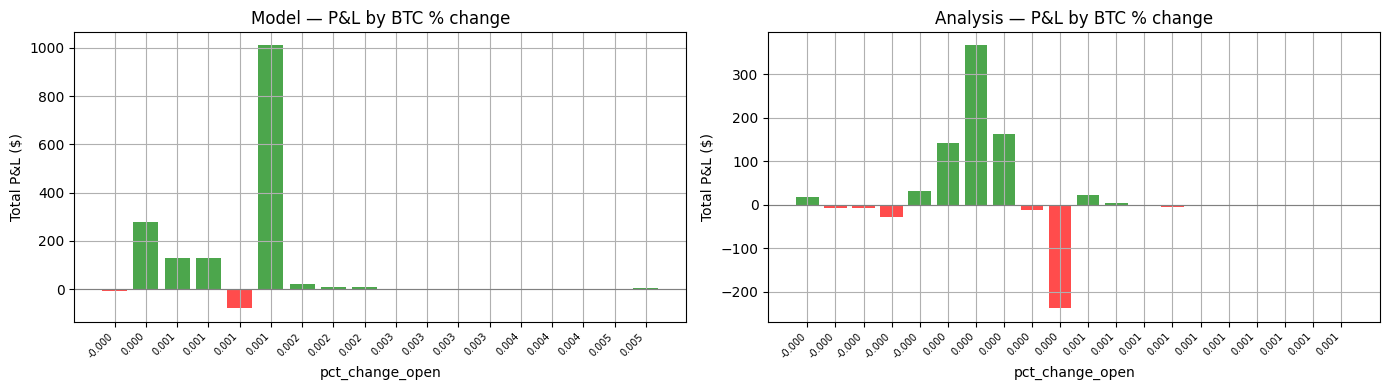

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, label in [
    (axes[0], model_df, 'Model'),
    (axes[1], analysis_df, 'Analysis'),
]:
    df = df.copy()
    df['pct_bin'] = pd.cut(df['pct_change_open'], bins=20)
    grp = df.groupby('pct_bin', observed=True).agg(
        n=('pnl', 'count'),
        total_pnl=('pnl', 'sum'),
    ).reset_index()
    grp['bin_mid'] = grp['pct_bin'].apply(lambda x: x.mid)

    color = ['green' if p >= 0 else 'red' for p in grp['total_pnl']]
    ax.bar(range(len(grp)), grp['total_pnl'], color=color, alpha=0.7)
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels([f"{v:.3f}" for v in grp['bin_mid']], rotation=45, ha='right', fontsize=7)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('pct_change_open')
    ax.set_ylabel('Total P&L ($)')
    ax.set_title(f'{label} — P&L by BTC % change')

plt.tight_layout()
plt.show()

## 7. Is the breakeven condition redundant?
Check how many trades pass edge+prob gates but fail the breakeven condition.

In [11]:
for df, label in [(model_df, 'Model'), (analysis_df, 'Analysis')]:
    df = df.copy()
    df['breakeven'] = df['yes_price'] / (1 - PM_FEE)
    df['pass_edge'] = df['edge'] >= 0.02
    df['pass_prob'] = df['predicted_prob'] >= 0.7
    df['pass_breakeven'] = df['predicted_prob'] > df['breakeven']

    both = df['pass_edge'] & df['pass_prob']
    filtered_by_breakeven = both & ~df['pass_breakeven']

    print(f'{label}:')
    print(f'  Pass edge+prob:                    {both.sum():,}')
    print(f'  Also filtered out by breakeven:    {filtered_by_breakeven.sum():,}')
    print(f'  => breakeven is redundant for {100*both.sum()/max(1,len(df)):.1f}% of trades')
    print()

Model:
  Pass edge+prob:                    9,251
  Also filtered out by breakeven:    0
  => breakeven is redundant for 100.0% of trades

Analysis:
  Pass edge+prob:                    6,948
  Also filtered out by breakeven:    0
  => breakeven is redundant for 100.0% of trades



## 8. NO bet opportunity
How many trades had a NO edge but were not taken?

In [12]:
for df, label in [(model_df, 'Model'), (analysis_df, 'Analysis')]:
    df = df.copy()
    df['no_prob'] = 1 - df['predicted_prob']
    df['no_edge'] = df['no_prob'] - df['no_price']
    df['would_win_no'] = ~df['resolved_yes']

    no_candidates = df[(df['no_edge'] >= 0.02) & (df['no_prob'] >= 0.7)]
    print(f'{label} — potential NO trades with edge>=0.02 and prob>=0.7:')
    print(f'  Count:    {len(no_candidates):,}')
    if len(no_candidates) > 0:
        win_rate = no_candidates['would_win_no'].mean()
        stake = df['stake'].iloc[0]
        pnl = no_candidates.apply(
            lambda r: stake * (1/r['no_price']) * (1 - PM_FEE) - stake if r['would_win_no'] else -stake,
            axis=1
        ).sum()
        print(f'  Win rate: {100*win_rate:.1f}%')
        print(f'  Sim P&L:  ${pnl:+.2f}')
    print()

Model — potential NO trades with edge>=0.02 and prob>=0.7:
  Count:    0

Analysis — potential NO trades with edge>=0.02 and prob>=0.7:
  Count:    0



## 9. Model vs Analysis comparison on same markets

In [13]:
shared_markets = set(model_df['market_id']) & set(analysis_df['market_id'])
print(f'Markets appearing in both: {len(shared_markets)}')

m = model_df[model_df['market_id'].isin(shared_markets)]
a = analysis_df[analysis_df['market_id'].isin(shared_markets)]

print(f'\nModel on shared markets:    trades={len(m):,}  pnl=${m["pnl"].sum():+.2f}  win={100*m["resolved_yes"].mean():.1f}%')
print(f'Analysis on shared markets: trades={len(a):,}  pnl=${a["pnl"].sum():+.2f}  win={100*a["resolved_yes"].mean():.1f}%')

Markets appearing in both: 112

Model on shared markets:    trades=7,548  pnl=$+360.46  win=72.8%
Analysis on shared markets: trades=5,659  pnl=$+383.25  win=70.8%


## 10. Probability Threshold Comparison

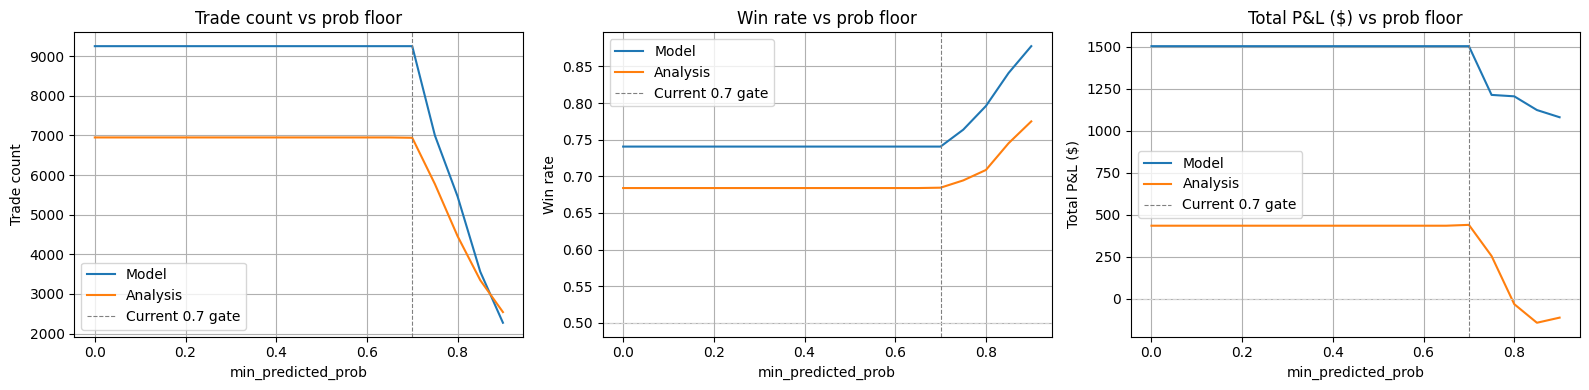

                                                        Model                        Analysis
                                 trades   win%      P&L     ROI    trades   win%      P&L     ROI
----------------------------------------------------------------------------------------------------
edge>=0.02, prob < 0.7                0      —        —       —         0      —        —       —
edge>=0.02, prob >= 0.7           9,251  74.1% +1503.92  +16.3%     6,948  68.4%  +435.64   +6.3%
edge>=0.02, any prob              9,251  74.1% +1503.92  +16.3%     6,948  68.4%  +435.64   +6.3%


In [14]:
MIN_EDGE = 0.02  # keep edge gate fixed, only vary the prob floor

# --- sweep min_predicted_prob ---
def prob_sweep(df: pd.DataFrame, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.0, 0.95, 0.05)
    rows = []
    for t in thresholds:
        sub = df[(df['edge'] >= MIN_EDGE) & (df['predicted_prob'] >= t)]
        if len(sub) == 0:
            rows.append({'min_prob': t, 'n': 0, 'win_rate': np.nan, 'total_pnl': 0, 'roi': np.nan})
            continue
        pnl = sub['pnl'].sum()
        rows.append({
            'min_prob': t,
            'n': len(sub),
            'win_rate': sub['resolved_yes'].mean(),
            'total_pnl': pnl,
            'roi': 100 * pnl / (len(sub) * df['stake'].iloc[0]),
        })
    return pd.DataFrame(rows)

model_psweep = prob_sweep(model_df)
analysis_psweep = prob_sweep(analysis_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, ylabel in [
    (axes[0], 'n', 'Trade count'),
    (axes[1], 'win_rate', 'Win rate'),
    (axes[2], 'total_pnl', 'Total P&L ($)'),
]:
    ax.plot(model_psweep['min_prob'], model_psweep[col], label='Model')
    ax.plot(analysis_psweep['min_prob'], analysis_psweep[col], label='Analysis')
    ax.axvline(0.7, color='gray', linestyle='--', linewidth=0.8, label='Current 0.7 gate')
    if col == 'win_rate':
        ax.axhline(0.5, color='lightgray', linestyle='--', linewidth=0.8)
    if col == 'total_pnl':
        ax.axhline(0, color='lightgray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('min_predicted_prob')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + ' vs prob floor')
    ax.legend()

plt.tight_layout()
plt.show()

# --- direct comparison: below vs above 0.7 ---
print(f"{'':30s} {'Model':>30s}  {'Analysis':>30s}")
print(f"{'':30s} {'trades':>8} {'win%':>6} {'P&L':>8} {'ROI':>7}  {'trades':>8} {'win%':>6} {'P&L':>8} {'ROI':>7}")
print('-' * 100)
for label, m_sub, a_sub in [
    ('edge>=0.02, prob < 0.7',
     model_df[(model_df['edge'] >= MIN_EDGE) & (model_df['predicted_prob'] < 0.7)],
     analysis_df[(analysis_df['edge'] >= MIN_EDGE) & (analysis_df['predicted_prob'] < 0.7)]),
    ('edge>=0.02, prob >= 0.7',
     model_df[(model_df['edge'] >= MIN_EDGE) & (model_df['predicted_prob'] >= 0.7)],
     analysis_df[(analysis_df['edge'] >= MIN_EDGE) & (analysis_df['predicted_prob'] >= 0.7)]),
    ('edge>=0.02, any prob',
     model_df[model_df['edge'] >= MIN_EDGE],
     analysis_df[analysis_df['edge'] >= MIN_EDGE]),
]:
    def fmt(sub):
        if len(sub) == 0:
            return f"{'0':>8} {'—':>6} {'—':>8} {'—':>7}"
        pnl = sub['pnl'].sum()
        roi = 100 * pnl / (len(sub) * sub['stake'].iloc[0])
        return f"{len(sub):>8,} {100*sub['resolved_yes'].mean():>5.1f}% {pnl:>+8.2f} {roi:>+6.1f}%"
    print(f"{label:30s} {fmt(m_sub)}  {fmt(a_sub)}")


## Exploration

In [15]:
model_df.head()

,trade_id,opened_at,market_id,yes_price,no_price,btc_usd,pct_change_open,time_remaining,spread,predicted_prob,edge,model_id,stake,resolved_yes,resolved_at,pnl
0,b5b23ccc-6812-4803-b51f-02da9c6844f1,2026-05-19 13:30:17.712927+00:00,0x3b324283510fe2fc0eb0d4191df9c42d73ec7080bb6a...,0.66,0.35,76660.71,0.000615,283,0.01,0.769381,0.109381,logistic_regression_20260519_132929,1.0,True,2026-05-19 13:35:10.324521+00:00,0.484848
1,4cef78ee-b75a-4897-a0c8-2b02058cba0b,2026-05-19 13:33:05.508171+00:00,0x3b324283510fe2fc0eb0d4191df9c42d73ec7080bb6a...,0.88,0.13,76750.00,0.001781,115,0.01,0.917098,0.037098,logistic_regression_20260519_133229,1.0,True,2026-05-19 13:35:10.324521+00:00,0.113636
2,f37256df-7e4d-4c6c-8e5a-f10cce1b5075,2026-05-19 13:33:06.540596+00:00,0x3b324283510fe2fc0eb0d4191df9c42d73ec7080bb6a...,0.89,0.14,76760.00,0.001911,114,0.03,0.937046,0.047046,logistic_regression_20260519_133229,1.0,True,2026-05-19 13:35:10.324521+00:00,0.101124
3,37f94918-b7af-4a81-8419-35cf2eb7a992,2026-05-19 13:36:01.264407+00:00,0xa4307cc9a6136a20107d2ac1288ae5226f8f6dc11e5f...,0.47,0.54,76944.00,0.000740,239,0.01,0.832270,0.362270,logistic_regression_20260519_133529,1.0,True,2026-05-19 13:40:00.507183+00:00,1.085106
4,3cd5d810-780b-4a81-8548-2b4add1ea9a2,2026-05-19 13:36:02.303254+00:00,0xa4307cc9a6136a20107d2ac1288ae5226f8f6dc11e5f...,0.47,0.54,76944.01,0.000740,238,0.01,0.831550,0.361550,logistic_regression_20260519_133529,1.0,True,2026-05-19 13:40:00.507183+00:00,1.085106
